In [23]:
!pip install yfinance

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [26]:
!pip install yfinance
import yfinance as yf

In [27]:
# Orijinal notebook'taki gibi son 5 yıllık veriyi indiriyoruz
df = yf.download("AAPL", period='5y')

# Veri setinin genel yapısını kontrol edelim
df.info()

/tmp/ipykernel_7747/1166181627.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", period='5y')
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2021-05-24 to 2026-05-22
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1256 non-null   float64
 1   (High, AAPL)    1256 non-null   float64
 2   (Low, AAPL)     1256 non-null   float64
 3   (Open, AAPL)    1256 non-null   float64
 4   (Volume, AAPL)  1256 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


In [28]:
# Orijinal mantıkla %70 eğitim, %30 doğrulama olarak ayırıyoruz
train_length = round(len(df) * 0.7)
lg = len(df)
val_length = lg - train_length

print('Toplam Gözlem Sayısı:', lg)
print('Eğitim Seti Boyutu:', train_length)
print('Doğrulama Seti Boyutu:', val_length)

# Apple'ın Kapanış (Close) fiyatlarını alıyoruz
train_data = df[('Close', 'AAPL')][:train_length]
val_data = df[('Close', 'AAPL')][train_length:]

# Matrise dönüştürme işlemi
train = train_data.values.reshape(-1, 1)

Toplam Gözlem Sayısı: 1256
Eğitim Seti Boyutu: 879
Doğrulama Seti Boyutu: 377


In [29]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train)

In [30]:
X_train = []
y_train = []

# Orijinal notebook'ta kullanılan pencere boyutuna (timestep) göre ayarlayabilirsiniz.
# Genelde borsa verilerinde son 50 veya 60 gün tercih edilir, biz burada 50 gün kabul edelim:
timesteps = 50

for i in range(timesteps, train_length):
    X_train.append(train_scaled[i-timesteps:i, 0])
    y_train.append(train_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# RNN girişi için 3 boyutlu matrise dönüştürme (samples, timesteps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [31]:
model = Sequential()

# İlk SimpleRNN Katmanı
model.add(SimpleRNN(units=50, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# İkinci SimpleRNN Katmanı
model.add(SimpleRNN(units=50, activation='tanh', return_sequences=True))
model.add(Dropout(0.2))

# Üçüncü SimpleRNN Katmanı
model.add(SimpleRNN(units=50, activation='tanh'))
model.add(Dropout(0.2))

# Çıkış Katmanı
model.add(Dense(units=1))

# Modelin derlenmesi (Compile)
model.compile(optimizer='adam', loss='mean_squared_error')

# Modelin eğitilmesi
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.2551
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1396
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1200
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0782
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0529
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0455
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0376
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0304
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0263
Epoch 10/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0232
Epoch 11/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0237
Epoch 12/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0199
Epoch 13/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0175
Epoch 14/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0157
Epoch 15/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0142
Epoch 16/20
26/

In [32]:
# Eğitim ve Doğrulama verilerini birleştirerek test girdisi oluşturma
dataset_total = pd.concat((train_data, val_data), axis=0)
inputs = dataset_total[len(dataset_total) - len(val_data) - timesteps:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_val = []
for i in range(timesteps, len(inputs)):
    X_val.append(inputs[i-timesteps:i, 0])

X_val = np.array(X_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# Model üzerinden tahminlerin alınması
predictions = model.predict(X_val)
# Ölçeklendirilmiş verileri orijinal fiyat ölçeğine geri getirme
predictions = scaler.inverse_transform(predictions)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


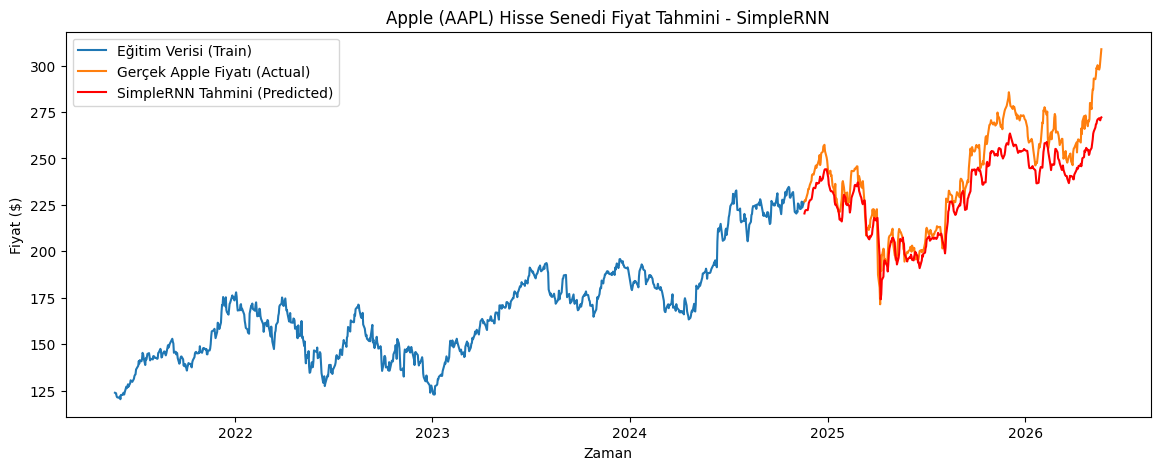

In [33]:
# Dataframe index'lerini kullanarak görselleştirme yapıyoruz
val_data_df = pd.DataFrame(val_data)
val_data_df['Predictions'] = predictions

plt.figure(figsize=(14, 5))
plt.plot(df[('Close', 'AAPL')][:train_length], label='Eğitim Verisi (Train)')
plt.plot(val_data_df[('Close', 'AAPL')], label='Gerçek Apple Fiyatı (Actual)')
plt.plot(val_data_df['Predictions'], label='SimpleRNN Tahmini (Predicted)', color='red')
plt.title('Apple (AAPL) Hisse Senedi Fiyat Tahmini - SimpleRNN')
plt.xlabel('Zaman')
plt.ylabel('Fiyat ($)')
plt.legend()
plt.show()